In [ ]:

import os
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures,
    OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    HuberRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


In [ ]:
# Cell 2: Load and merge datasets

# Old distance data: trip_id, Price_old (piastres), distance_km
df_dist = pd.read_csv("Predicted_Prices.csv")
df_dist = df_dist.rename(columns={"Price": "Price_old"})

# New enriched data: trip_id, route_id, route_long_name_x, agency_id, Price (EGP), passangers
df_meta = pd.read_csv("prices.csv")

print("Distances file:")
display(df_dist.head())

print("\nNew enriched file:")
display(df_meta.head())

# Merge on trip_id (inner = only trips that exist in both)
df = df_dist.merge(df_meta, on="trip_id", how="inner", suffixes=("", "_extra"))

print("\nMerged dataset:")
display(df.head())
print("\nMerged shape:", df.shape)

# In merged df:
# - Price_old   : integer (piastres)
# - Price       : float (EGP) with NaNs (unknowns to predict)
# - distance_km : numeric
# - route_id, route_long_name_x, agency_id, passangers : route metadata

print("\nPrice (EGP) NaNs (unknowns to predict):", df["Price"].isna().sum())
print("Price (EGP) non-NaNs (known labels):   ", df["Price"].notna().sum())


Distances file:


,trip_id,Price_old,distance_km
0,-Q2gVX9GgVSEtVr-yv6Nf-07:00:00,434,1.6327
1,-vGMBy-ffWWJVczaRlv5z-07:00:00,662,10.1883
2,025LCvbNrkhPcZFND6SfE-07:00:00,900,9.0486
3,0I4f41gSbP4Nhu5ZbZZGv-07:00:00,473,3.0758
4,0eMropKVlaFEwtKn18KiF-07:00:00,421,1.1165



New enriched file:


,trip_id,route_id,route_long_name_x,agency_id,Price,passangers
0,I2ar40PiiuS-HMI9_KCLc-07:00:00,dpTyJ7ihIOXu0gGo2F3iz,Asafra - El-Sa'ah (Clock Square),P_O_14,4.25,14
1,40rOFL2qzN26P2ty7q_b9-07:00:00,o8mSXE7IgJWToUsU4NnFr,El-Mansheya - El-Sa'ah (Clock Square),P_O_14,8.25,14
2,tl8ZQbvleCGCbWdgkRkZg-07:00:00,ndixtJMAJzaQiITLSzYz_,Al-Seyouf (Falaky) - El-Awayed,P_O_14,NaN,14
3,9ByH2YQ54cshi1Sj8kgPQ-07:00:00,xkITynYnba-VdPTlpu5kL,El-Mansheya - Victoria station,P_O_14,NaN,14
4,6d2W3a35jKEGSEjY9OqMB-07:00:00,ndixtJMAJzaQiITLSzYz_,Al-Seyouf (Falaky) - El-Awayed,P_O_14,NaN,14



Merged dataset:


,trip_id,Price_old,distance_km,route_id,route_long_name_x,agency_id,Price,passangers
0,-Q2gVX9GgVSEtVr-yv6Nf-07:00:00,434,1.6327,lgA0Qn219kk386RQHCTQ7,Bakus - El-Awayed,P_O_14,NaN,14
1,-vGMBy-ffWWJVczaRlv5z-07:00:00,662,10.1883,d1tk5YD606wPnGF4CLm4i,El-Mawqaf El-Geded - Sidi Gabir,P_O_14,NaN,14
2,025LCvbNrkhPcZFND6SfE-07:00:00,900,9.0486,BDGXXpou9Eb38xEVTNUs2,Amreyya - Kilo 21,P_O_14,9.0,14
3,0I4f41gSbP4Nhu5ZbZZGv-07:00:00,473,3.0758,tMb6GY09D_zaob3QQV8vM,Al-Maraghi - El-Awayed,P_O_14,NaN,14
4,0eMropKVlaFEwtKn18KiF-07:00:00,421,1.1165,9Ge1SSHI5IgHaGIK61A7q,Abo Soliman - El-Sa'ah (Clock Square),P_B_8,NaN,8



Merged shape: (163, 8)

Price (EGP) NaNs (unknowns to predict): 102
Price (EGP) non-NaNs (known labels):    61


In [ ]:
# Cell 3: Separate known (training) and unknown (prediction target) prices

# Known prices: actual bus fares we will train on (Price not NaN)
df_known = df[df["Price"].notna()].copy().reset_index(drop=True)

# Unknown prices: we'll predict these with the final model (Price is NaN)
df_unknown = df[df["Price"].isna()].copy().reset_index(drop=True)

print("Known rows:", df_known.shape)
print("Unknown rows:", df_unknown.shape)

# Target variable for training
y_full = df_known["Price"].values  # in EGP


Known rows: (61, 8)
Unknown rows: (102, 8)


In [ ]:
# Cell 4: Feature engineering (numeric + categorical)

# Create engineered features on the FULL merged df,
# then we'll subset df_known / df_unknown for modeling.

df["distance_km_sq"] = df["distance_km"] ** 2
df["distance_km_cu"] = df["distance_km"] ** 3
df["distance_log"]   = np.log1p(df["distance_km"])

# Per-passenger features (captures crowding / bus vs microbus effects)
df["dist_per_passenger"]      = df["distance_km"] / df["passangers"]
df["log_dist_per_passenger"]  = np.log1p(df["dist_per_passenger"])

# We'll drop route_long_name_x (text) to avoid huge one-hot duplication;
# route_id already uniquely identifies the route.
df_features = df.drop(columns=["Price_old"])  # keep Price (EGP) + route_id + agency_id + passangers + distances

# Now build feature sets only for rows with known prices
df_known_features = df_features[df["Price"].notna()].copy().reset_index(drop=True)
df_unknown_features = df_features[df["Price"].isna()].copy().reset_index(drop=True)

# Explicitly define which columns are used as features
numeric_features = [
    "distance_km",
    "distance_km_sq",
    "distance_km_cu",
    "distance_log",
    "passangers",
    "dist_per_passenger",
    "log_dist_per_passenger",
]

categorical_features = [
    "route_id",
    "agency_id",
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Features matrix for known rows
X_full = df_known_features[numeric_features + categorical_features]
y_full = df_known["Price"].values  # re-assign just for clarity

display(X_full.head())


Numeric features: ['distance_km', 'distance_km_sq', 'distance_km_cu', 'distance_log', 'passangers', 'dist_per_passenger', 'log_dist_per_passenger']
Categorical features: ['route_id', 'agency_id']


,distance_km,distance_km_sq,distance_km_cu,distance_log,passangers,dist_per_passenger,log_dist_per_passenger,route_id,agency_id
0,9.0486,81.877162,740.873688,2.307433,14,0.646329,0.498548,BDGXXpou9Eb38xEVTNUs2,P_O_14
1,3.8860,15.100996,58.682470,1.586374,8,0.485750,0.395920,D7IwqxPBMcEQiGv3sjC3s,P_B_8
2,14.7617,217.907787,3216.689378,2.757583,14,1.054407,0.719987,o8mSXE7IgJWToUsU4NnFr,P_O_14
3,32.0498,1027.189680,32921.223807,3.498016,14,2.289271,1.190666,SqToUMEw-z1wSe52v0JGh,P_O_14
4,19.0671,363.554302,6931.926239,2.999082,14,1.361936,0.859482,KNOT7t80YXwsfYupjUiTk,P_O_14


In [ ]:
# Cell 5: Train/Val/Test split on KNOWN prices

idx = np.arange(len(df_known))
train_val_idx, test_idx = train_test_split(idx, test_size=0.20, random_state=42)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=42)
# 0.25 of 0.8 = 0.2 → 60/20/20

X_train = X_full.iloc[train_idx].reset_index(drop=True)
y_train = y_full[train_idx]
X_val   = X_full.iloc[val_idx].reset_index(drop=True)
y_val   = y_full[val_idx]
X_test  = X_full.iloc[test_idx].reset_index(drop=True)
y_test  = y_full[test_idx]

print("Train shape:", X_train.shape)
print("Val shape:  ", X_val.shape)
print("Test shape: ", X_test.shape)


Train shape: (36, 9)
Val shape:   (12, 9)
Test shape:  (13, 9)


In [ ]:
# Cell 6: Metrics helpers & bus-style rounding

def metrics_dict(y_true, y_pred, n_features: int):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    return {
        "R2": r2,
        "Adj_R2": adj_r2,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
    }

def print_metrics(name, m):
    print(
        f"{name:25s} | "
        f"R2={m['R2']:.4f} | "
        f"Adj_R2={m['Adj_R2']:.4f} | "
        f"MSE={m['MSE']:.3f} | "
        f"MAE={m['MAE']:.3f} | "
        f"RMSE={m['RMSE']:.3f}"
    )

def round_bus_style(vals):
    """
    Round to nearest:
      - 0.00, 0.25, 0.50, 1.00 EGP within each pound
    using your custom cut points.
    """
    scalar = np.isscalar(vals)
    arr = np.array([vals]) if scalar else np.asarray(vals)
    out = []

    for v in arr:
        pounds = int(np.floor(v))
        dec = v - pounds
        if dec < 0.125:
            r = pounds + 0.0
        elif dec < 0.375:
            r = pounds + 0.25
        elif dec < 0.75:
            r = pounds + 0.5
        else:
            r = pounds + 1.0
        out.append(round(r, 2))

    return out[0] if scalar else np.array(out)


In [ ]:
# Cell 7: Preprocessor (ColumnTransformer)

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['distance_km', 'distance_km_sq',
                                  'distance_km_cu', 'distance_log',
                                  'passangers', 'dist_per_passenger',
                                  'log_dist_per_passenger']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['route_id', 'agency_id'])])


In [ ]:
# Cell 8: Grid search helper + baseline LinearRegression

results = []
fitted_models = {}   # name -> pipeline
feature_kind = {}    # here always "full", but kept for clarity

def run_grid_search(name, estimator, param_grid, X_tr, y_tr, X_v, y_v):
    """
    Wrap an estimator in a Pipeline(preprocessor + reg),
    run GridSearchCV, evaluate on validation set, save metrics.
    """
    print(f"\n=== Training {name} ===")

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("reg", estimator),
    ])

    gs = GridSearchCV(
        pipe,
        param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    gs.fit(X_tr, y_tr)
    best = gs.best_estimator_
    print("Best params:", gs.best_params_)

    # Extract effective number of features after preprocessing
    reg = best.named_steps["reg"]
    if hasattr(reg, "n_features_in_"):
        n_features_eff = reg.n_features_in_
    else:
        # Fallback: approximate with numeric+categorical count
        n_features_eff = len(numeric_features) + len(categorical_features)

    val_pred = best.predict(X_v)
    val_metrics = metrics_dict(y_v, val_pred, n_features=n_features_eff)
    print_metrics(f"{name} (val)", val_metrics)

    fitted_models[name] = best
    feature_kind[name] = "full"

    return {
        "model": name,
        "best_params": str(gs.best_params_),
        "R2_val": val_metrics["R2"],
        "Adj_R2_val": val_metrics["Adj_R2"],
        "MSE_val": val_metrics["MSE"],
        "MAE_val": val_metrics["MAE"],
        "RMSE_val": val_metrics["RMSE"],
    }

# Baseline Linear Regression WITHOUT grid (just log-distance+features)
lr = LinearRegression()
pipe_lr = Pipeline([
    ("preprocess", preprocessor),
    ("reg", lr),
])
pipe_lr.fit(X_train, y_train)
val_pred_lr = pipe_lr.predict(X_val)

if hasattr(lr, "n_features_in_"):
    n_features_lr = lr.n_features_in_
else:
    n_features_lr = len(numeric_features) + len(categorical_features)

m_lr = metrics_dict(y_val, val_pred_lr, n_features_lr)
print_metrics("LinearRegression (val)", m_lr)

fitted_models["LinearRegression"] = pipe_lr
feature_kind["LinearRegression"] = "full"

results.append({
    "model": "LinearRegression",
    "best_params": "{}",
    "R2_val": m_lr["R2"],
    "Adj_R2_val": m_lr["Adj_R2"],
    "MSE_val": m_lr["MSE"],
    "MAE_val": m_lr["MAE"],
    "RMSE_val": m_lr["RMSE"],
})


LinearRegression (val)    | R2=0.4887 | Adj_R2=1.2083 | MSE=2.871 | MAE=0.868 | RMSE=1.695


In [ ]:
# Cell 8: Grid search helper + baseline LinearRegression

results = []
fitted_models = {}   # name -> pipeline
feature_kind = {}    # here always "full", but kept for clarity

def run_grid_search(name, estimator, param_grid, X_tr, y_tr, X_v, y_v):
    """
    Wrap an estimator in a Pipeline(preprocessor + reg),
    run GridSearchCV, evaluate on validation set, save metrics.
    """
    print(f"\n=== Training {name} ===")

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("reg", estimator),
    ])

    gs = GridSearchCV(
        pipe,
        param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    gs.fit(X_tr, y_tr)
    best = gs.best_estimator_
    print("Best params:", gs.best_params_)

    # Extract effective number of features after preprocessing
    reg = best.named_steps["reg"]
    if hasattr(reg, "n_features_in_"):
        n_features_eff = reg.n_features_in_
    else:
        # Fallback: approximate with numeric+categorical count
        n_features_eff = len(numeric_features) + len(categorical_features)

    val_pred = best.predict(X_v)
    val_metrics = metrics_dict(y_v, val_pred, n_features=n_features_eff)
    print_metrics(f"{name} (val)", val_metrics)

    fitted_models[name] = best
    feature_kind[name] = "full"

    return {
        "model": name,
        "best_params": str(gs.best_params_),
        "R2_val": val_metrics["R2"],
        "Adj_R2_val": val_metrics["Adj_R2"],
        "MSE_val": val_metrics["MSE"],
        "MAE_val": val_metrics["MAE"],
        "RMSE_val": val_metrics["RMSE"],
    }

# Baseline Linear Regression WITHOUT grid (just log-distance+features)
lr = LinearRegression()
pipe_lr = Pipeline([
    ("preprocess", preprocessor),
    ("reg", lr),
])
pipe_lr.fit(X_train, y_train)
val_pred_lr = pipe_lr.predict(X_val)

if hasattr(lr, "n_features_in_"):
    n_features_lr = lr.n_features_in_
else:
    n_features_lr = len(numeric_features) + len(categorical_features)

m_lr = metrics_dict(y_val, val_pred_lr, n_features_lr)
print_metrics("LinearRegression (val)", m_lr)

fitted_models["LinearRegression"] = pipe_lr
feature_kind["LinearRegression"] = "full"

results.append({
    "model": "LinearRegression",
    "best_params": "{}",
    "R2_val": m_lr["R2"],
    "Adj_R2_val": m_lr["Adj_R2"],
    "MSE_val": m_lr["MSE"],
    "MAE_val": m_lr["MAE"],
    "RMSE_val": m_lr["RMSE"],
})


LinearRegression (val)    | R2=0.4887 | Adj_R2=1.2083 | MSE=2.871 | MAE=0.868 | RMSE=1.695


In [ ]:
# Cell 9: Ridge, Lasso, ElasticNet, Polynomial Regression

# Ridge
ridge = Ridge(random_state=42)
ridge_grid = {
    "reg__alpha": [0.01, 0.1, 1, 10, 100]
}
results.append(
    run_grid_search("Ridge", ridge, ridge_grid,
                    X_train, y_train, X_val, y_val)
)

# Lasso
lasso = Lasso(random_state=42, max_iter=10000)
lasso_grid = {
    "reg__alpha": [0.001, 0.01, 0.1, 1, 10]
}
results.append(
    run_grid_search("Lasso", lasso, lasso_grid,
                    X_train, y_train, X_val, y_val)
)

# Elastic Net
en = ElasticNet(random_state=42, max_iter=10000)
en_grid = {
    "reg__alpha": [0.001, 0.01, 0.1, 1],
    "reg__l1_ratio": [0.1, 0.5, 0.9],
}
results.append(
    run_grid_search("ElasticNet", en, en_grid,
                    X_train, y_train, X_val, y_val)
)

# Polynomial Regression on distance_log only (extra experiment)
# Here we build a separate pipeline to explicitly respect the log-distance insight.
poly_pipe_base = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])

# We'll feed it only the distance_log feature (plus we could add passangers if needed).
X_train_poly = df_known_features.loc[train_idx, ["distance_log"]]
X_val_poly   = df_known_features.loc[val_idx, ["distance_log"]]

poly_grid = {
    "poly__degree": [2, 3]
}

print("\n=== Training PolynomialRegression (distance_log only) ===")
gs_poly = GridSearchCV(poly_pipe_base, poly_grid, cv=5, scoring="r2", n_jobs=-1)
gs_poly.fit(X_train_poly, y_train)
best_poly = gs_poly.best_estimator_
print("Best params:", gs_poly.best_params_)

n_features_poly = best_poly.named_steps["reg"].n_features_in_
val_pred_poly = best_poly.predict(X_val_poly)
m_poly = metrics_dict(y_val, val_pred_poly, n_features_poly)
print_metrics("PolynomialRegression_log (val)", m_poly)

fitted_models["PolynomialRegression_log"] = best_poly
feature_kind["PolynomialRegression_log"] = "log_only"

results.append({
    "model": "PolynomialRegression_log",
    "best_params": str(gs_poly.best_params_),
    "R2_val": m_poly["R2"],
    "Adj_R2_val": m_poly["Adj_R2"],
    "MSE_val": m_poly["MSE"],
    "MAE_val": m_poly["MAE"],
    "RMSE_val": m_poly["RMSE"],
})



=== Training Ridge ===
Best params: {'reg__alpha': 1}
Ridge (val)               | R2=0.8568 | Adj_R2=1.0583 | MSE=0.804 | MAE=0.766 | RMSE=0.897

=== Training Lasso ===
Best params: {'reg__alpha': 0.01}
Lasso (val)               | R2=0.8899 | Adj_R2=1.0448 | MSE=0.618 | MAE=0.590 | RMSE=0.786

=== Training ElasticNet ===
Best params: {'reg__alpha': 0.01, 'reg__l1_ratio': 0.9}
ElasticNet (val)          | R2=0.8784 | Adj_R2=1.0495 | MSE=0.683 | MAE=0.631 | RMSE=0.826

=== Training PolynomialRegression (distance_log only) ===
Best params: {'poly__degree': 2}
PolynomialRegression_log (val) | R2=0.7478 | Adj_R2=0.6918 | MSE=1.416 | MAE=1.003 | RMSE=1.190


In [ ]:
# Cell 10: DecisionTree, RandomForest, GradientBoosting

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt_grid = {
    "reg__max_depth": [2, 3, 4, 5, None],
    "reg__min_samples_split": [2, 5, 10],
}
results.append(
    run_grid_search("DecisionTree", dt, dt_grid,
                    X_train, y_train, X_val, y_val)
)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf_grid = {
    "reg__n_estimators": [100, 200],
    "reg__max_depth": [None, 4, 6],
    "reg__min_samples_leaf": [1, 2, 4],
}
results.append(
    run_grid_search("RandomForest", rf, rf_grid,
                    X_train, y_train, X_val, y_val)
)

# Gradient Boosting
gbr = GradientBoostingRegressor(random_state=42)
gbr_grid = {
    "reg__n_estimators": [100, 200],
    "reg__learning_rate": [0.05, 0.1],
    "reg__max_depth": [2, 3, 4],
}
results.append(
    run_grid_search("GradientBoosting", gbr, gbr_grid,
                    X_train, y_train, X_val, y_val)
)



=== Training DecisionTree ===
Best params: {'reg__max_depth': 3, 'reg__min_samples_split': 5}
DecisionTree (val)        | R2=0.7365 | Adj_R2=1.1074 | MSE=1.480 | MAE=0.822 | RMSE=1.217

=== Training RandomForest ===
Best params: {'reg__max_depth': None, 'reg__min_samples_leaf': 2, 'reg__n_estimators': 100}
RandomForest (val)        | R2=0.7383 | Adj_R2=1.1066 | MSE=1.470 | MAE=0.791 | RMSE=1.212

=== Training GradientBoosting ===
Best params: {'reg__learning_rate': 0.05, 'reg__max_depth': 3, 'reg__n_estimators': 100}
GradientBoosting (val)    | R2=0.8014 | Adj_R2=1.0809 | MSE=1.115 | MAE=0.628 | RMSE=1.056


In [ ]:
# Cell 11: SVR, KNN, Huber, optional XGBoost & LightGBM

# SVR
svr = SVR()
svr_grid = {
    "reg__C": [0.1, 1, 10],
    "reg__epsilon": [0.01, 0.1],
    "reg__kernel": ["rbf", "linear"],
}
results.append(
    run_grid_search("SVR", svr, svr_grid,
                    X_train, y_train, X_val, y_val)
)

# KNN
knn = KNeighborsRegressor()
knn_grid = {
    "reg__n_neighbors": [3, 5, 7],
    "reg__weights": ["uniform", "distance"],
}
results.append(
    run_grid_search("KNN", knn, knn_grid,
                    X_train, y_train, X_val, y_val)
)

# Huber Regressor
huber = HuberRegressor()
huber_grid = {
    "reg__alpha": [0.0001, 0.001, 0.01],
    "reg__epsilon": [1.1, 1.35, 1.5],
}
results.append(
    run_grid_search("HuberRegressor", huber, huber_grid,
                    X_train, y_train, X_val, y_val)
)

# XGBoost (optional)
if HAS_XGB:
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        eval_metric="rmse",
    )
    xgb_grid = {
        "reg__n_estimators": [200],
        "reg__max_depth": [3, 4],
        "reg__learning_rate": [0.05, 0.1],
        "reg__subsample": [0.8],
        "reg__colsample_bytree": [0.8],
    }
    results.append(
        run_grid_search("XGBoost", xgb, xgb_grid,
                        X_train, y_train, X_val, y_val)
    )

# LightGBM (optional)
if HAS_LGBM:
    lgbm = LGBMRegressor(random_state=42)
    lgbm_grid = {
        "reg__n_estimators": [200],
        "reg__max_depth": [-1, 4],
        "reg__learning_rate": [0.05, 0.1],
        "reg__num_leaves": [15, 31],
    }
    results.append(
        run_grid_search("LightGBM", lgbm, lgbm_grid,
                        X_train, y_train, X_val, y_val)
    )

results_df = pd.DataFrame(results)
display(results_df.sort_values("Adj_R2_val", ascending=False).head())



=== Training SVR ===
Best params: {'reg__C': 1, 'reg__epsilon': 0.1, 'reg__kernel': 'linear'}
SVR (val)                 | R2=0.8739 | Adj_R2=1.0514 | MSE=0.708 | MAE=0.686 | RMSE=0.841

=== Training KNN ===
Best params: {'reg__n_neighbors': 3, 'reg__weights': 'uniform'}
KNN (val)                 | R2=0.8271 | Adj_R2=1.0704 | MSE=0.971 | MAE=0.694 | RMSE=0.985

=== Training HuberRegressor ===
Best params: {'reg__alpha': 0.0001, 'reg__epsilon': 1.35}
HuberRegressor (val)      | R2=0.9039 | Adj_R2=1.0392 | MSE=0.540 | MAE=0.593 | RMSE=0.735

=== Training XGBoost ===
Best params: {'reg__colsample_bytree': 0.8, 'reg__learning_rate': 0.05, 'reg__max_depth': 3, 'reg__n_estimators': 200, 'reg__subsample': 0.8}
XGBoost (val)             | R2=0.7727 | Adj_R2=1.0926 | MSE=1.276 | MAE=0.711 | RMSE=1.130

=== Training LightGBM ===
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-

,model,best_params,R2_val,Adj_R2_val,MSE_val,MAE_val,RMSE_val
12,LightGBM,"{'reg__learning_rate': 0.05, 'reg__max_depth':...",-0.017389,1.414492,5.713542,1.958333,2.390302
0,LinearRegression,{},0.488702,1.208306,2.871389,0.867948,1.694517
5,DecisionTree,"{'reg__max_depth': 3, 'reg__min_samples_split'...",0.736477,1.107361,1.479917,0.822049,1.216518
6,RandomForest,"{'reg__max_depth': None, 'reg__min_samples_lea...",0.738292,1.106622,1.469722,0.791452,1.212321
11,XGBoost,"{'reg__colsample_bytree': 0.8, 'reg__learning_...",0.772741,1.092587,1.276263,0.711089,1.129718


In [ ]:
# Cell 12: Evaluate on test set + summary CSV

test_rows = []
for _, row in results_df.iterrows():
    name = row["model"]
    model = fitted_models[name]

    if name == "PolynomialRegression_log":
        # Uses only distance_log as input
        X_test_used = df_known_features.loc[test_idx, ["distance_log"]]
        reg = model.named_steps["reg"]
        n_features_used = reg.n_features_in_
    else:
        X_test_used = X_test
        reg = model.named_steps["reg"]
        n_features_used = getattr(reg, "n_features_in_", len(numeric_features) + len(categorical_features))

    y_pred_test = model.predict(X_test_used)
    m_test = metrics_dict(y_test, y_pred_test, n_features_used)

    test_rows.append({
        "model": name,
        "R2_test": m_test["R2"],
        "Adj_R2_test": m_test["Adj_R2"],
        "MSE_test": m_test["MSE"],
        "MAE_test": m_test["MAE"],
        "RMSE_test": m_test["RMSE"],
    })

test_df = pd.DataFrame(test_rows)

summary_df = results_df.merge(test_df, on="model")
summary_df = summary_df.sort_values(
    ["Adj_R2_test", "R2_test", "MSE_test"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("Top models (by test Adj_R2):")
display(summary_df.head())

summary_path = "model_comparison_results.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved model comparison to: {summary_path}")


Top models (by test Adj_R2):


,model,best_params,R2_val,Adj_R2_val,MSE_val,MAE_val,RMSE_val,R2_test,Adj_R2_test,MSE_test,MAE_test,RMSE_test
0,LightGBM,"{'reg__learning_rate': 0.05, 'reg__max_depth':...",-0.017389,1.414492,5.713542,1.958333,2.390302,-0.000168,1.461616,4.948317,1.682692,2.224481
1,LinearRegression,{},0.488702,1.208306,2.871389,0.867948,1.694517,0.471187,1.244068,2.616296,0.756569,1.617497
2,Ridge,{'reg__alpha': 1},0.856844,1.058323,0.803950,0.766008,0.896632,0.691720,1.142283,1.525212,0.907900,1.234995
3,RandomForest,"{'reg__max_depth': None, 'reg__min_samples_lea...",0.738292,1.106622,1.469722,0.791452,1.212321,0.736541,1.121596,1.303459,0.785301,1.141691
4,DecisionTree,"{'reg__max_depth': 3, 'reg__min_samples_split'...",0.736477,1.107361,1.479917,0.822049,1.216518,0.746262,1.117110,1.255367,0.749199,1.120432


Saved model comparison to: model_comparison_results.csv


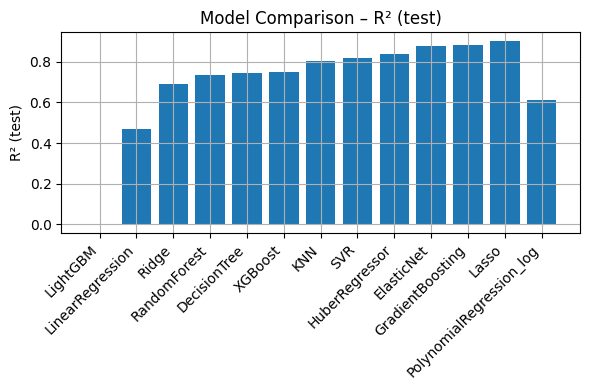

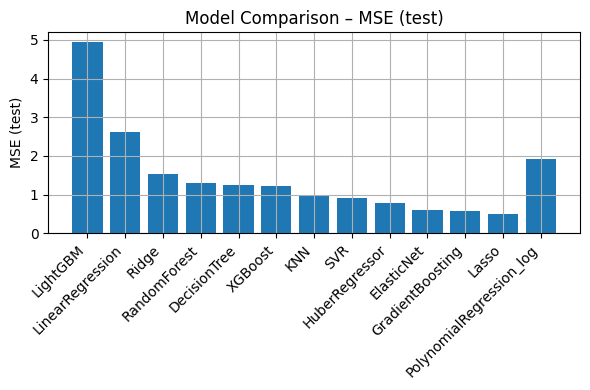

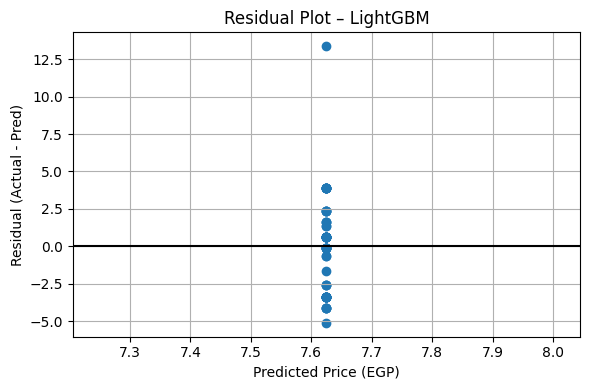

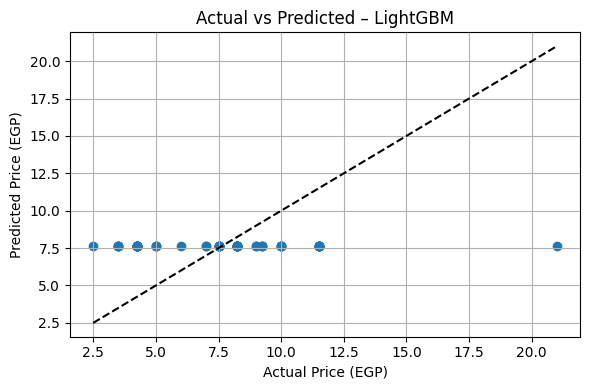

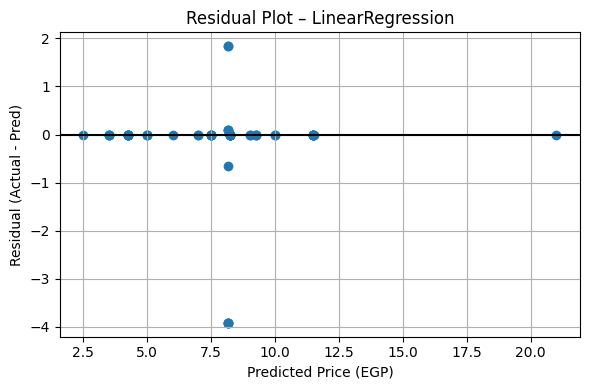

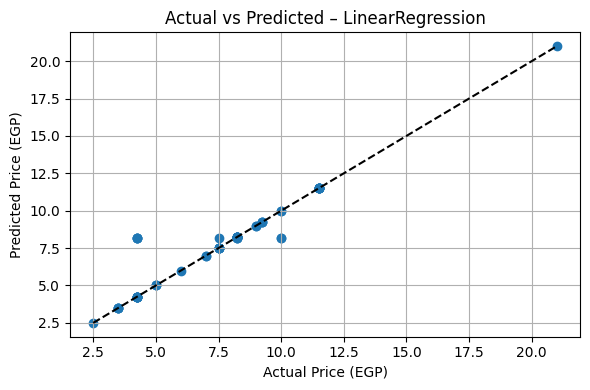

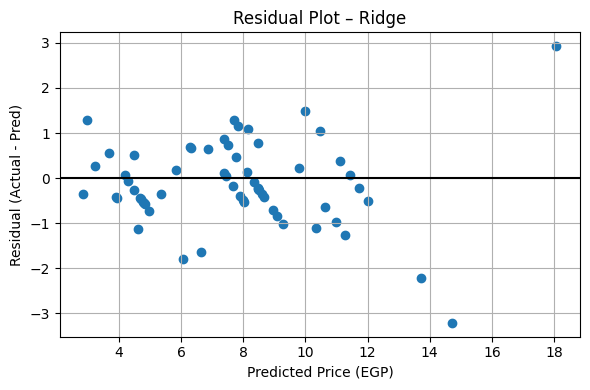

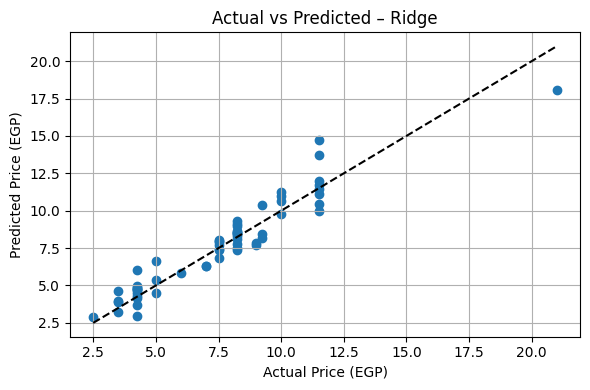

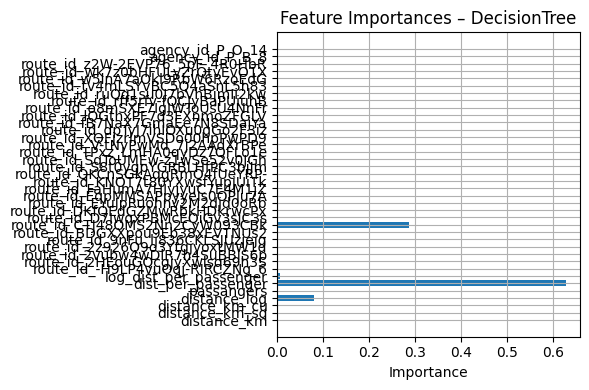

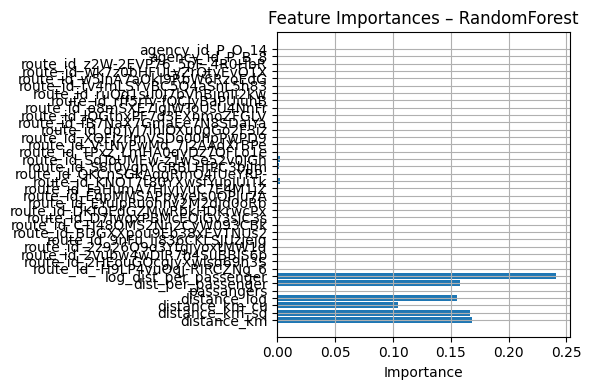

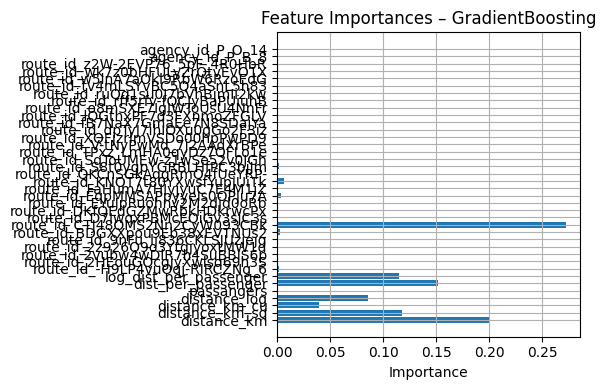

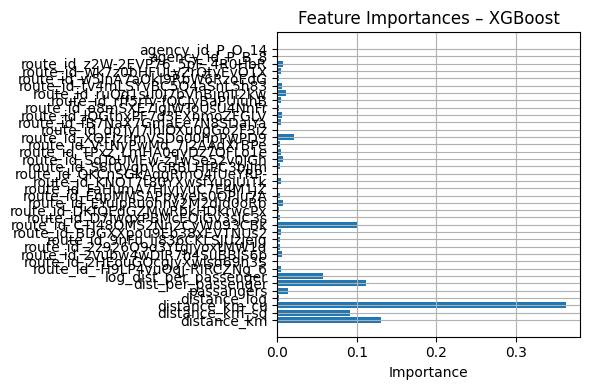

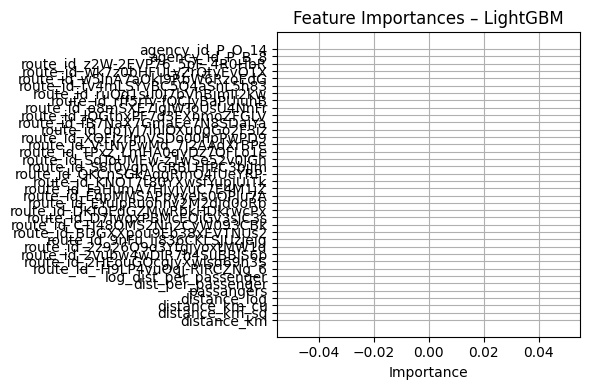

In [ ]:
# Cell 13: Visualization & analysis

# --- Model comparison bar plots ---
plt.figure()
plt.bar(summary_df["model"], summary_df["R2_test"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² (test)")
plt.title("Model Comparison – R² (test)")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(summary_df["model"], summary_df["MSE_test"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("MSE (test)")
plt.title("Model Comparison – MSE (test)")
plt.tight_layout()
plt.show()

# --- Residual plots & actual vs predicted for top 3 ---
top3 = summary_df["model"].head(3).tolist()

for name in top3:
    model = fitted_models[name]
    if name == "PolynomialRegression_log":
        X_all = df_known_features[["distance_log"]]
        y_all = y_full
    else:
        X_all = X_full
        y_all = y_full

    y_pred_all = model.predict(X_all)
    residuals = y_all - y_pred_all

    # Residuals
    plt.figure()
    plt.scatter(y_pred_all, residuals)
    plt.axhline(0, color="black")
    plt.xlabel("Predicted Price (EGP)")
    plt.ylabel("Residual (Actual - Pred)")
    plt.title(f"Residual Plot – {name}")
    plt.tight_layout()
    plt.show()

    # Actual vs predicted
    plt.figure()
    plt.scatter(y_all, y_pred_all)
    lims = [min(y_all.min(), y_pred_all.min()), max(y_all.max(), y_pred_all.max())]
    plt.plot(lims, lims, "k--")
    plt.xlabel("Actual Price (EGP)")
    plt.ylabel("Predicted Price (EGP)")
    plt.title(f"Actual vs Predicted – {name}")
    plt.tight_layout()
    plt.show()

# --- Feature importance for tree-based models ---
tree_models = ["DecisionTree", "RandomForest", "GradientBoosting"]
if HAS_XGB:  tree_models.append("XGBoost")
if HAS_LGBM: tree_models.append("LightGBM")

# Get processed feature names from preprocessor
ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
num_feature_names = numeric_features
all_feature_names = num_feature_names + cat_feature_names

for name in tree_models:
    if name not in fitted_models:
        continue
    model = fitted_models[name]
    reg = model.named_steps["reg"]
    if not hasattr(reg, "feature_importances_"):
        continue

    importances = reg.feature_importances_
    # Safety: truncate names if lengths differ
    n = min(len(all_feature_names), len(importances))
    plt.figure()
    plt.barh(all_feature_names[:n], importances[:n])
    plt.xlabel("Importance")
    plt.title(f"Feature Importances – {name}")
    plt.tight_layout()
    plt.show()


In [ ]:
# Cell 14: TripPricePredictor wrapper class (with new columns)

# Choose best model from summary_df
best_row = summary_df.iloc[0]
best_model_name = best_row["model"]
print("Best model:", best_model_name)

best_pipeline = fitted_models[best_model_name]

# Refit the best pipeline on ALL known data
if best_model_name == "PolynomialRegression_log":
    X_all_train = df_known_features[["distance_log"]]
else:
    X_all_train = X_full

y_all_train = y_full
best_pipeline.fit(X_all_train, y_all_train)

# Defaults for convenience when user supplies only distance
default_route_id = df_known["route_id"].mode()[0]
default_agency_id = df_known["agency_id"].mode()[0]
default_passangers = df_known["passangers"].median()

print("Default route_id:   ", default_route_id)
print("Default agency_id:  ", default_agency_id)
print("Default passangers: ", default_passangers)

class TripPricePredictor(BaseEstimator, RegressorMixin):
    """
    Super-powered wrapper:
      - holds a fitted sklearn pipeline (preprocessor + best model)
      - supports batch predictions
      - applies business rounding
      - uses distance_km + route_id + agency_id + passangers
    """
    def __init__(self, pipeline, default_route_id=None, default_agency_id=None, default_passangers=None):
        self.pipeline = pipeline
        self.default_route_id = default_route_id
        self.default_agency_id = default_agency_id
        self.default_passangers = default_passangers

    def fit(self, X, y):
        """
        X: DataFrame with columns matching numeric_features + categorical_features
        y: prices (EGP)
        """
        self.pipeline.fit(X, y)
        return self

    def _build_dataframe(self, distance_km, route_id, agency_id, passangers):
        # Convert all to numpy arrays and broadcast scalars
        dist = np.array(distance_km)
        scalar = np.isscalar(distance_km)
        if dist.ndim == 0:
            dist = dist.reshape(1)
        n = dist.shape[0]

        if route_id is None:
            route_id = np.array([self.default_route_id] * n)
        else:
            route_id = np.array(route_id)
            if route_id.ndim == 0:
                route_id = np.array([route_id] * n)

        if agency_id is None:
            agency_id = np.array([self.default_agency_id] * n)
        else:
            agency_id = np.array(agency_id)
            if agency_id.ndim == 0:
                agency_id = np.array([agency_id] * n)

        if passangers is None:
            passangers = np.array([self.default_passangers] * n)
        else:
            passangers = np.array(passangers, dtype=float)
            if passangers.ndim == 0:
                passangers = np.array([passangers] * n)

        dfX = pd.DataFrame({
            "distance_km": dist.astype(float),
            "passangers": passangers.astype(float),
            "route_id": route_id,
            "agency_id": agency_id,
        })

        # Recreate engineered features
        dfX["distance_km_sq"] = dfX["distance_km"] ** 2
        dfX["distance_km_cu"] = dfX["distance_km"] ** 3
        dfX["distance_log"] = np.log1p(dfX["distance_km"])
        dfX["dist_per_passenger"] = dfX["distance_km"] / dfX["passangers"]
        dfX["log_dist_per_passenger"] = np.log1p(dfX["dist_per_passenger"])

        # Order columns to match training
        all_cols = numeric_features + categorical_features
        dfX = dfX[all_cols]

        return dfX, scalar

    def predict(self, distance_km, route_id=None, agency_id=None, passangers=None):
        """
        distance_km: scalar or list/array
        route_id, agency_id, passangers: optional (if None, use defaults)
        Returns bus-style rounded prices.
        """
        dfX, scalar = self._build_dataframe(distance_km, route_id, agency_id, passangers)
        raw_pred = self.pipeline.predict(dfX)
        rounded = round_bus_style(raw_pred)
        return rounded[0] if scalar else rounded

    def predict_from_df(self, dfX):
        """
        Convenience: predict from a pre-built DataFrame with all feature columns.
        """
        raw_pred = self.pipeline.predict(dfX[numeric_features + categorical_features])
        return round_bus_style(raw_pred)


Best model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 132
[LightGBM] [Info] Number of data points in the train set: 61, number of used features: 6
[LightGBM] [Info] Start training from score 7.557377
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

In [ ]:
# Cell 15: Build final TripPricePredictor, save, predict unknowns, export Excel

final_model = TripPricePredictor(
    pipeline=best_pipeline,
    default_route_id=default_route_id,
    default_agency_id=default_agency_id,
    default_passangers=default_passangers,
)

# We already fitted best_pipeline on all known data, so final_model is ready to use.

MODEL_PATH = "trip_price_model_pipeline.joblib"
dump(final_model, MODEL_PATH)
print(f"Saved production model to: {MODEL_PATH}")

# ---- Predict for unknown prices ----
if len(df_unknown) > 0:
    # Build feature DataFrame for unknowns
    dfU = df_unknown.copy()
    dfU["distance_km_sq"] = dfU["distance_km"] ** 2
    dfU["distance_km_cu"] = dfU["distance_km"] ** 3
    dfU["distance_log"]   = np.log1p(dfU["distance_km"])
    dfU["dist_per_passenger"] = dfU["distance_km"] / dfU["passangers"]
    dfU["log_dist_per_passenger"] = np.log1p(dfU["dist_per_passenger"])

    X_unknown = dfU[numeric_features + categorical_features]
    raw_pred_unknown = best_pipeline.predict(X_unknown)
    df_unknown["Price_pred"] = round_bus_style(raw_pred_unknown)

    # Export predictions
    df_unknown[["trip_id", "Price_pred"]].to_excel("predicted_unknown_prices.xlsx", index=False)
    print("Saved predicted_unknown_prices.xlsx")
else:
    pd.DataFrame(columns=["trip_id", "Price_pred"]).to_excel("predicted_unknown_prices.xlsx", index=False)
    print("No unknown trips, wrote empty predicted_unknown_prices.xlsx")

# ---- All trips with final prices ----
# Use actual Price where known, predicted where unknown
df_all = df.copy()

df_all = df_all.merge(
    df_unknown[["trip_id", "Price_pred"]],
    on="trip_id",
    how="left"
)

df_all["Price_final"] = df_all["Price"]
mask_unknown = df_all["Price"].isna()
df_all.loc[mask_unknown, "Price_final"] = df_all.loc[mask_unknown, "Price_pred"]

df_all_out = df_all[["trip_id", "route_id", "agency_id", "distance_km", "passangers", "Price_final"]]

df_all_out.to_excel("all_trips_with_prices.xlsx", index=False)
print("Saved all_trips_with_prices.xlsx")


Saved production model to: trip_price_model_pipeline.joblib
Saved predicted_unknown_prices.xlsx
Saved all_trips_with_prices.xlsx


In [ ]:
# Cell 16: Sanity tests with loaded model

loaded_model = load("trip_price_model_pipeline.joblib")

# Example single distances (using defaults for route/agency/passengers)
single_distances = [1, 5.5, 10, 25, 50]
edge_distances   = [0.5, 100]

print("Single distances:", single_distances)
print("Predicted prices (EGP):", loaded_model.predict(single_distances))

print("\nEdge distances:", edge_distances)
print("Predicted prices (EGP):", loaded_model.predict(edge_distances))

# Example: specific route + agency + passenger counts
example_routes = df_known["route_id"].head(3).tolist()
example_agencies = df_known["agency_id"].head(3).tolist()
example_pass = df_known["passangers"].head(3).tolist()
example_dists = df_known["distance_km"].head(3).tolist()

print("\nRoute-aware predictions:")
print("Distances:", example_dists)
print("Route IDs:", example_routes)
print("Agencies:", example_agencies)
print("Passengers:", example_pass)
print("Prices:", loaded_model.predict(
    example_dists,
    route_id=example_routes,
    agency_id=example_agencies,
    passangers=example_pass
))


Single distances: [1, 5.5, 10, 25, 50]
Predicted prices (EGP): [ 4.5   4.5   7.25 10.5  10.5 ]

Edge distances: [0.5, 100]
Predicted prices (EGP): [ 4.5 10.5]

Route-aware predictions:
Distances: [9.0486, 3.886, 14.7617]
Route IDs: ['BDGXXpou9Eb38xEVTNUs2', 'D7IwqxPBMcEQiGv3sjC3s', 'o8mSXE7IgJWToUsU4NnFr']
Agencies: ['P_O_14', 'P_B_8', 'P_O_14']
Passengers: [14, 8, 14]
Prices: [7.25 4.5  8.  ]


In [ ]:
def metrics_dict(y_true, y_pred, n_features: int):
    import numpy as np

    r2 = r2_score(y_true, y_pred)
    n = len(y_true)

    if n > n_features + 1:
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    else:
        adj_r2 = np.nan   # not defined / not reliable

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    return {
        "R2": r2,
        "Adj_R2": adj_r2,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
    }
# Rebuild summary_df as before, then:

summary_df = summary_df.sort_values(
    ["R2_test", "MSE_test"],
    ascending=[False, True]
).reset_index(drop=True)

print("Top models by R2_test, then MSE_test:")
display(summary_df.head())


Top models by R2_test, then MSE_test:


,model,best_params,R2_val,Adj_R2_val,MSE_val,MAE_val,RMSE_val,R2_test,Adj_R2_test,MSE_test,MAE_test,RMSE_test
0,Lasso,{'reg__alpha': 0.01},0.889949,1.044836,0.618033,0.589739,0.786151,0.900947,1.045717,0.490062,0.557438,0.700044
1,GradientBoosting,"{'reg__learning_rate': 0.05, 'reg__max_depth':...",0.801440,1.080895,1.115088,0.627954,1.055977,0.882385,1.054284,0.581899,0.440608,0.762823
2,ElasticNet,"{'reg__alpha': 0.01, 'reg__l1_ratio': 0.9}",0.878394,1.049543,0.682923,0.631481,0.826391,0.879838,1.055459,0.594500,0.619435,0.771038
3,HuberRegressor,"{'reg__alpha': 0.0001, 'reg__epsilon': 1.35}",0.903875,1.039162,0.539829,0.592676,0.734731,0.839812,1.073933,0.792529,0.728732,0.890241
4,SVR,"{'reg__C': 1, 'reg__epsilon': 0.1, 'reg__kerne...",0.873920,1.051366,0.708053,0.686276,0.841459,0.816993,1.084465,0.905423,0.762447,0.951537
